In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd #data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import re 
from collections import Counter
!pip install matplotlib-venn -q

from matplotlib_venn import venn3
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/codinix/transaction-data/QVI_transaction_data.xlsx
/kaggle/input/datasets/codinix/qvl-purchase-behaviour/QVI_purchase_behaviour.csv


In [2]:
purchase = pd.read_csv('/kaggle/input/datasets/codinix/qvl-purchase-behaviour/QVI_purchase_behaviour.csv')
transaction = pd.read_excel('/kaggle/input/datasets/codinix/transaction-data/QVI_transaction_data.xlsx') 
#for correcting the date time formate
transaction['DATE'] = pd.to_datetime(transaction['DATE'], unit='D', origin='1899-12-30')

In [3]:
#Joining 2 dataset for better insight  
!pip install duckdb -q
import duckdb
merge = """
            SELECT t.*,p.LIFESTAGE,p.PREMIUM_CUSTOMER
            FROM transaction AS t
            LEFT JOIN purchase AS p
            ON t.LYLTY_CARD_NBR = p.LYLTY_CARD_NBR
        """
merge_result = duckdb.query(merge).to_df()
merge_result.head(11)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-11-08,9,9339,8804,91,CCs Tasty Cheese 175g,2,4.2,YOUNG FAMILIES,Mainstream
1,2018-08-03,9,9462,8970,73,Smiths Crinkle Cut Salt & Vinegar 170g,2,5.8,YOUNG FAMILIES,Mainstream
2,2019-06-11,9,9487,8999,84,GrnWves Plus Btroot & Chilli Jam 180g,2,6.2,YOUNG FAMILIES,Mainstream
3,2018-10-28,9,9499,9010,13,Red Rock Deli Thai Chilli&Lime 150g,2,5.4,YOUNG FAMILIES,Mainstream
4,2019-03-19,9,9499,9011,69,Smiths Chip Thinly S/Cream&Onion 175g,1,3.0,YOUNG FAMILIES,Mainstream
5,2018-07-12,10,10038,9256,13,Red Rock Deli Thai Chilli&Lime 150g,2,5.4,YOUNG FAMILIES,Mainstream
6,2018-07-18,10,10038,9257,41,Doritos Salsa Mild 300g,2,5.2,YOUNG FAMILIES,Mainstream
7,2018-10-17,10,10038,9258,53,RRD Sweet Chilli & Sour Cream 165g,2,6.0,YOUNG FAMILIES,Mainstream
8,2018-11-07,10,10038,9259,105,Woolworths Cheese Rings 190g,2,3.6,YOUNG FAMILIES,Mainstream
9,2019-04-26,10,10038,9260,41,Doritos Salsa Mild 300g,2,5.2,YOUNG FAMILIES,Mainstream


In [4]:
#looking out for various anomalies 
# 1st null or na anomalies in the cols of Product Quantity & Total_Sales
print("Count of Null/NA values per column:")
print(merge_result.isnull().sum())

merge_result['PROD_QTY'] = merge_result['PROD_QTY'].fillna(0)
merge_result['TOT_SALES'] = merge_result['TOT_SALES'].fillna(0)

# Filling other categorical nulls with 'Unknown'
merge_result['LIFESTAGE'] = merge_result['LIFESTAGE'].fillna('Unknown')
merge_result['PREMIUM_CUSTOMER'] = merge_result['PREMIUM_CUSTOMER'].fillna('Unknown')

print("\nNull values after cleaning:")
print(merge_result.isnull().sum())

# 2nd Checking for if there are any -ve entries due to refunds.
negatives = merge_result[(merge_result['PROD_QTY'] <= 0) | (merge_result['TOT_SALES'] <= 0)]
print(f"Found {len(negatives)} rows with zero or negative sales/quantity.")

# 3rd Extreme Outliners 
print(merge_result[['PROD_QTY', 'TOT_SALES']].describe())

# 4th Counting exact duplicate rows
duplicate_count = merge_result.duplicated().sum()
print(f"Found {duplicate_count} duplicate rows.")

# after the 4th we got one duplicate row and we have to remove it 
duplicate_rows = merge_result[merge_result.duplicated(keep=False)]
print("Here are the duplicated rows:")
print(duplicate_rows)

merge_result = merge_result.drop_duplicates()

remaining_duplicates = merge_result.duplicated().sum()
print(f"\nDuplicates remaining after cleaning: {remaining_duplicates}")

Count of Null/NA values per column:
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Null values after cleaning:
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
Found 0 rows with zero or negative sales/quantity.
            PROD_QTY      TOT_SALES
count  264836.000000  264836.000000
mean        1.907309       7.304200
std         0.643654       3.083226
min         1.000000       1.500000
25%         2.000000       5.400000
50%         2.000000       7.400000
75%         2.000000       9.200000
max       200.000000     650.000000
Found 1 duplicate rows.
Here are the duplicated rows:
            DATE  STORE_NBR  LYLTY_CARD_

In [5]:
# identifying how many catagory of products are in the store
#finding the unique product 
unique_products = merge_result['PROD_NAME'].unique()
all_text =' '.join(unique_products).lower()
words = re.findall(r'\b[a-z]+\b', all_text)
stop_words = {'and', 'the', 'of', 'in', 'with', 'salt', 'cut', 'pack', 'bag'}
meaningful_words = [word for word in words if word not in stop_words]
word_counts = Counter(meaningful_words)
common_words_df = pd.DataFrame(word_counts.most_common(30), columns=['Keyword', 'Frequency_Across_Products'])
common_words_df.head(15)

,Keyword,Frequency_Across_Products
0,chips,21
1,smiths,16
2,crinkle,14
3,kettle,13
4,cheese,12
5,original,10
6,chip,9
7,doritos,9
8,salsa,9
9,rrd,8


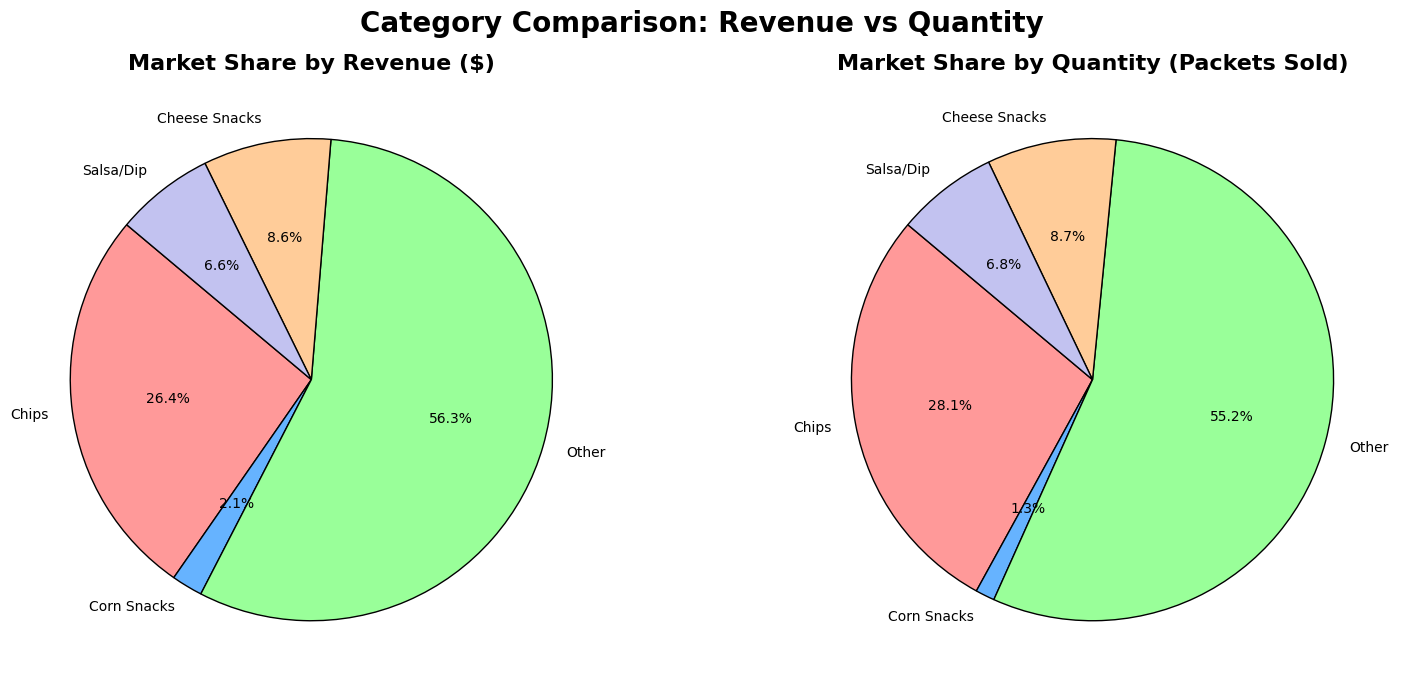

In [6]:
# shows the percentage of each item based on revenue and quantity
category_query = """
SELECT 
    CASE 
        WHEN PROD_NAME ILIKE '%chip%' THEN 'Chips'
        WHEN PROD_NAME ILIKE '%cheese%' OR PROD_NAME ILIKE '%cc%' THEN 'Cheese Snacks'
        WHEN PROD_NAME ILIKE '%pop%' THEN 'Popcorn'
        WHEN PROD_NAME ILIKE '%corn%' THEN 'Corn Snacks'
        WHEN PROD_NAME ILIKE '%salsa%' THEN 'Salsa/Dip'
        ELSE 'Other'
    END AS Category,
    SUM(PROD_QTY) AS Total_Quantity,
    SUM(TOT_SALES) AS Total_Revenue
FROM merge_result
GROUP BY Category
"""
category_df = duckdb.query(category_query).to_df()
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']
# PIE CHART 1: REVENUE
axes[0].pie(
    category_df['Total_Revenue'], 
    labels=category_df['Category'], 
    autopct='%1.1f%%',
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title('Market Share by Revenue ($)', fontsize=16, fontweight='bold')

# PIE CHART 2: QUANTITY
axes[1].pie(
    category_df['Total_Quantity'], 
    labels=category_df['Category'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Market Share by Quantity (Packets Sold)', fontsize=16, fontweight='bold')

plt.suptitle('Category Comparison: Revenue vs Quantity', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_17/798345637.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


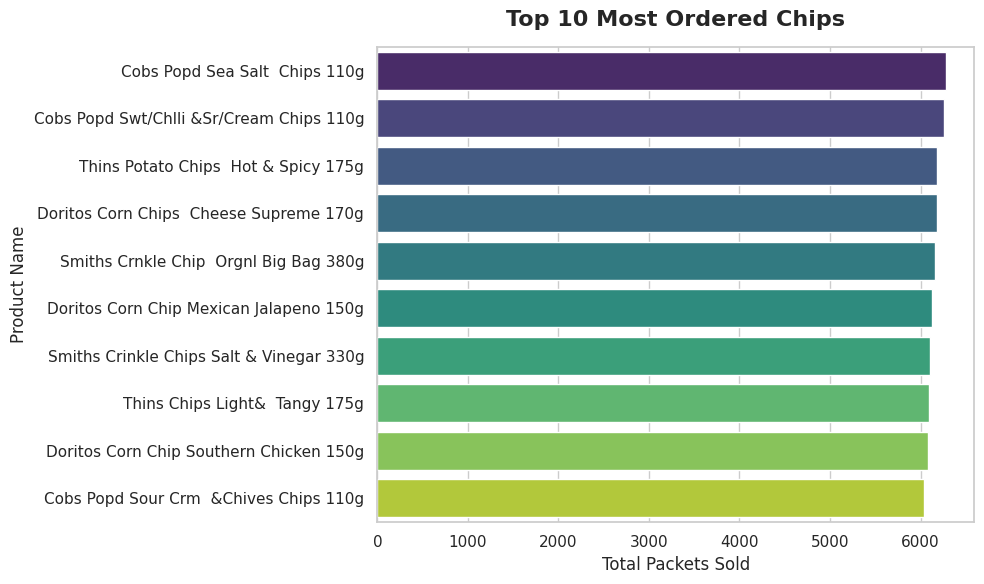

In [7]:
#from the above that we can take notes of various things.
# the chips makes up over 28% of the quantity and over 26% of the revenue is genrated from chips related products 
# top 10 chips by total quantity sold
top_chips_query = """
    SELECT 
        PROD_NAME, 
        SUM(PROD_QTY) AS Total_Quantity
    FROM merge_result
    WHERE PROD_NAME ILIKE '%chip%'
    GROUP BY PROD_NAME
    ORDER BY Total_Quantity DESC
    LIMIT 10 
"""
top_chips_df = duckdb.query(top_chips_query).to_df()
top_chips_df.head()

# Set up the size and style of the chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    x='Total_Quantity', 
    y='PROD_NAME', 
    data=top_chips_df, 
    palette='viridis' #
)

#  Adding clean labels and a title
plt.title('Top 10 Most Ordered Chips', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Packets Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_17/2228308504.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


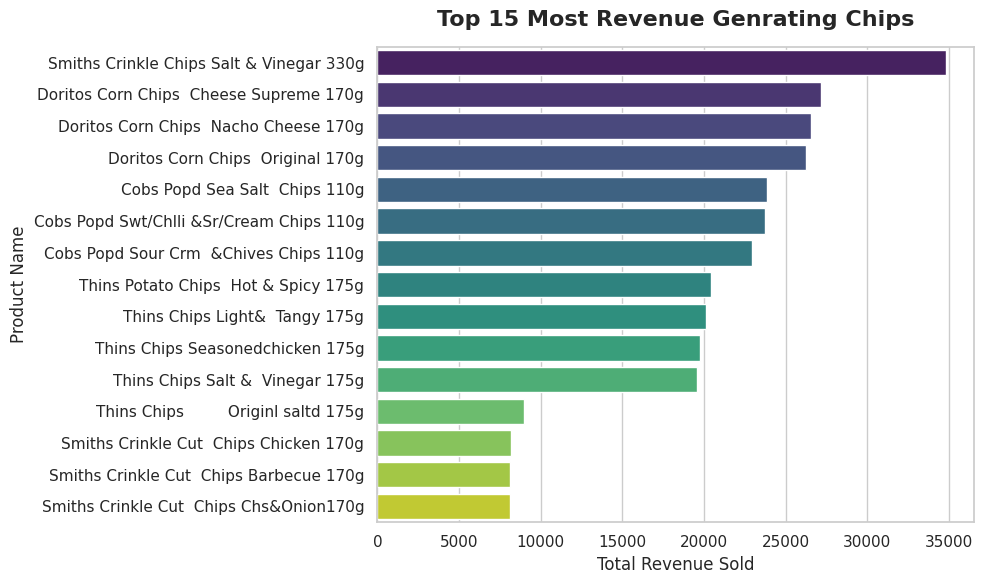

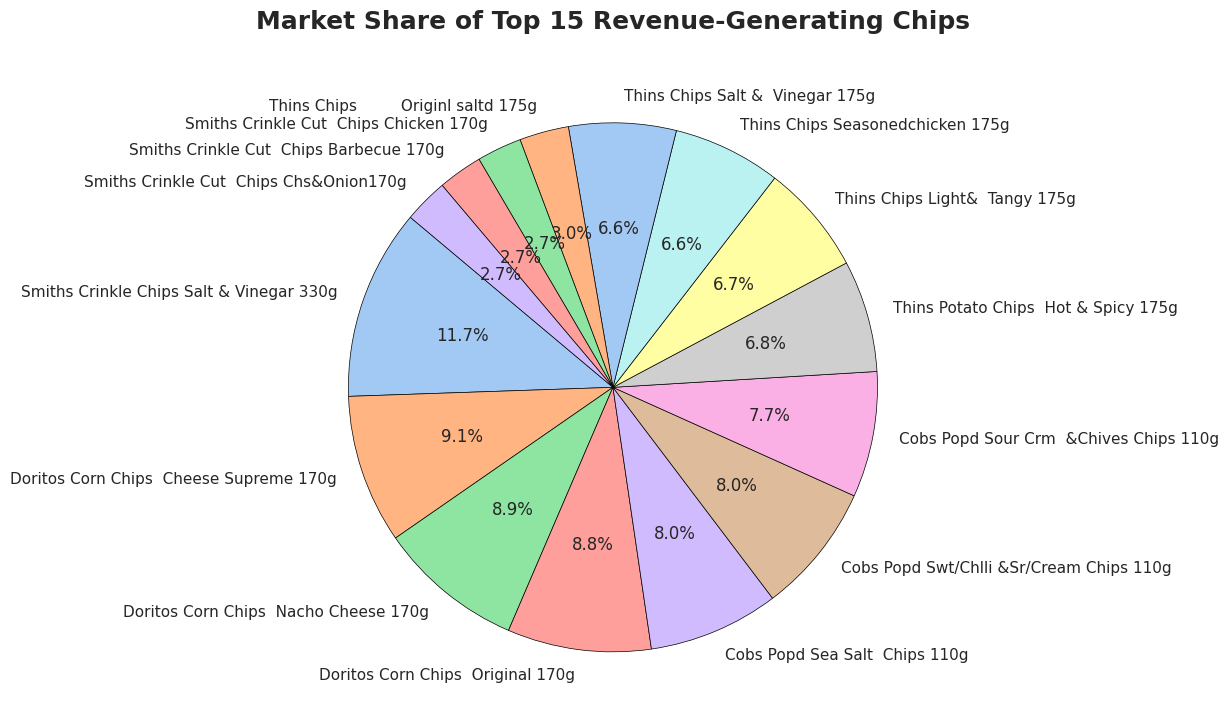

In [8]:
# from the previous query we get the most selling chips by volume.
# this time the metric is how much Revenue are they genrating for the shop
top_chips_query = """
    SELECT 
        PROD_NAME, 
        SUM(TOT_SALES) AS Total_Sales
    FROM merge_result
    WHERE PROD_NAME ILIKE '%chips%'
    GROUP BY PROD_NAME
    ORDER BY Total_Sales DESC
    LIMIT 15 
"""
top_chips_df = duckdb.query(top_chips_query).to_df()
top_chips_df.head()

# Set up the size and style of the chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    x='Total_Sales', 
    y='PROD_NAME', 
    data=top_chips_df, 
    palette='viridis'
)

#  Adding clean labels and a title
plt.title('Top 15 Most Revenue Genrating Chips', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Revenue Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 12))

# for seeing the market share between the top 15 chips
colors = sns.color_palette('pastel', 15)

# Plotting the Pie Chart
plt.pie(top_chips_df['Total_Sales'], 
        labels=top_chips_df['PROD_NAME'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})

plt.title('Market Share of Top 15 Revenue-Generating Chips', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# by running this query we have found the several things 
#1.the most selling chips by revenue is the smiths followed by the doritos
#2. by the pack size the 330gm are leading with 11.7% followed by 2nd with 9.1%
#3.the observation i made is that by the help of the pie chart that the 170-175gm by collective
# they are leading the market with staggering 55.8% in the top 15 market by the revenue

<Figure size 640x480 with 0 Axes>

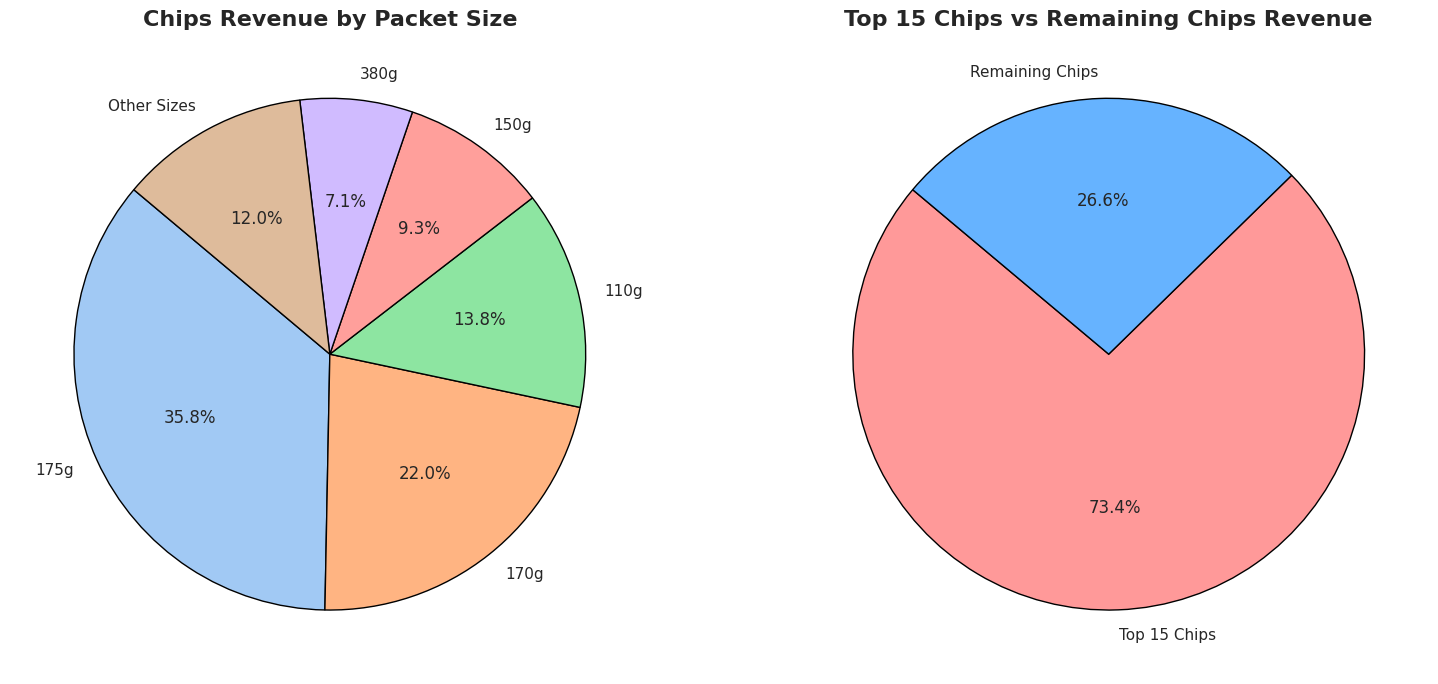

In [9]:
# this query is to find 2 things 1.how much is the share of top 15 selling chips in the total chips market
# 2. how much the share of revenue by weight of the chips 
packet_size_query = r"""
SELECT 
    REGEXP_EXTRACT(PROD_NAME, '\d+') || 'g' AS Packet_Size,
    SUM(TOT_SALES) AS Total_Revenue
FROM merge_result
WHERE PROD_NAME ILIKE '%chip%'
GROUP BY Packet_Size
ORDER BY Total_Revenue DESC
"""
packet_size_df = duckdb.query(packet_size_query).to_df()

# To make the pie chart readable, let's keep the Top 5 sizes and group the rest as 'Other'
top_sizes = packet_size_df.head(5)
other_revenue = packet_size_df['Total_Revenue'][5:].sum()

if other_revenue > 0:
    other_df = pd.DataFrame({'Packet_Size': ['Other Sizes'], 'Total_Revenue': [other_revenue]})
    plot_size_df = pd.concat([top_sizes, other_df], ignore_index=True)
else:
    plot_size_df = packet_size_df


top15_vs_all_query = """
WITH ChipSales AS (
    SELECT PROD_NAME, SUM(TOT_SALES) AS TOTAL_REVENUE
    FROM merge_result
    WHERE PROD_NAME ILIKE '%chip%'
    GROUP BY PROD_NAME
),
RankedChips AS (
    SELECT 
        PROD_NAME, 
        TOTAL_REVENUE,
        ROW_NUMBER() OVER(ORDER BY TOTAL_REVENUE DESC) as rank
    FROM ChipSales
)
SELECT 
    CASE WHEN rank <= 15 THEN 'Top 15 Chips' ELSE 'Remaining Chips' END AS Category,
    SUM(TOTAL_REVENUE) AS Total_Revenue
FROM RankedChips
GROUP BY Category
"""
top15_comp_df = duckdb.query(top15_vs_all_query).to_df()

colors_sizes = sns.color_palette('pastel')[0:len(plot_size_df)]
axes[0].pie(plot_size_df['Total_Revenue'], labels=plot_size_df['Packet_Size'], autopct='%1.1f%%', 
            startangle=140, colors=colors_sizes, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Chips Revenue by Packet Size', fontsize=16, fontweight='bold')

colors_comp = ['#ff9999', '#66b3ff']
axes[1].pie(top15_comp_df['Total_Revenue'], labels=top15_comp_df['Category'], autopct='%1.1f%%', 
            startangle=140, colors=colors_comp, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Top 15 Chips vs Remaining Chips Revenue', fontsize=16, fontweight='bold')

plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(16, 7)) 

# Pie Chart 1: Packet Sizes
colors_sizes = sns.color_palette('pastel')[0:len(plot_size_df)]
axes[0].pie(plot_size_df['Total_Revenue'], labels=plot_size_df['Packet_Size'], autopct='%1.1f%%', 
            startangle=140, colors=colors_sizes, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Chips Revenue by Packet Size', fontsize=16, fontweight='bold')

# Pie Chart 2: Top 15 vs All Others
colors_comp = ['#ff9999', '#66b3ff']
axes[1].pie(top15_comp_df['Total_Revenue'], labels=top15_comp_df['Category'], autopct='%1.1f%%', 
            startangle=140, colors=colors_comp, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Top 15 Chips vs Remaining Chips Revenue', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


In [10]:
# for finding the total number of chips bought by the specific age group and customer status 
chips = """
        SELECT PROD_NAME , LIFESTAGE, PREMIUM_CUSTOMER, SUM(PROD_QTY) AS Total_Quantity,
        SUM(TOT_SALES)/COUNT(DISTINCT LYLTY_CARD_NBR) AS Avg_spending_per_person,
        SUM(TOT_SALES) AS Total_Spending
        FROM merge_result
        WHERE PROD_NAME ILIKE '%chip%'
        GROUP BY PROD_NAME,LIFESTAGE,PREMIUM_CUSTOMER
        ORDER BY Total_Spending DESC
        """
chips_result = duckdb.query(chips).to_df()
chips_result.head()

,PROD_NAME,LIFESTAGE,PREMIUM_CUSTOMER,Total_Quantity,Avg_spending_per_person,Total_Spending
0,Smiths Crnkle Chip Orgnl Big Bag 380g,YOUNG SINGLES/COUPLES,Mainstream,596.0,11.057862,3516.4
1,Smiths Crinkle Chips Salt & Vinegar 330g,YOUNG SINGLES/COUPLES,Mainstream,582.0,10.701290,3317.4
2,Smiths Crinkle Chips Salt & Vinegar 330g,OLDER FAMILIES,Budget,559.0,11.461511,3186.3
3,Smiths Crnkle Chip Orgnl Big Bag 380g,OLDER FAMILIES,Budget,507.0,11.684766,2991.3
4,Smiths Crnkle Chip Orgnl Big Bag 380g,RETIREES,Mainstream,467.0,11.292213,2755.3


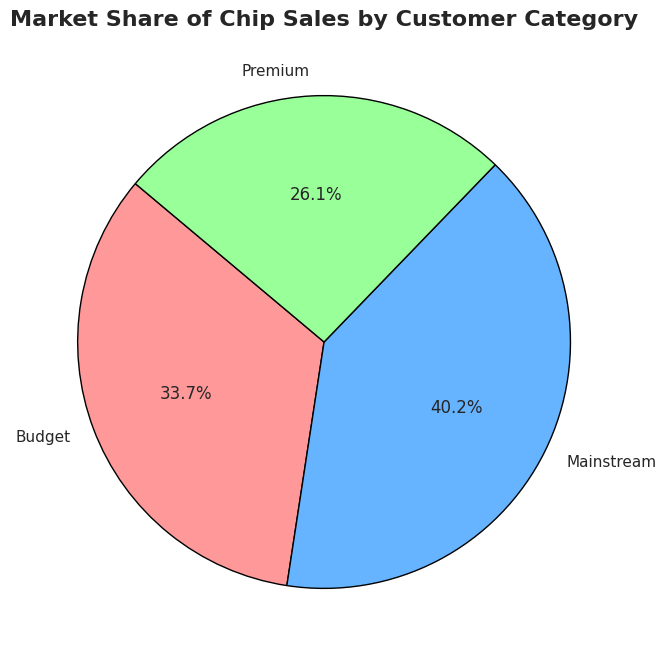

                LIFESTAGE  TOTAL_SALES
0   OLDER SINGLES/COUPLES     105931.2
1                RETIREES      95448.3
2          OLDER FAMILIES      94413.8
3          YOUNG FAMILIES      85164.7
4   YOUNG SINGLES/COUPLES      68446.4
5  MIDAGE SINGLES/COUPLES      49138.1
6            NEW FAMILIES      13045.8


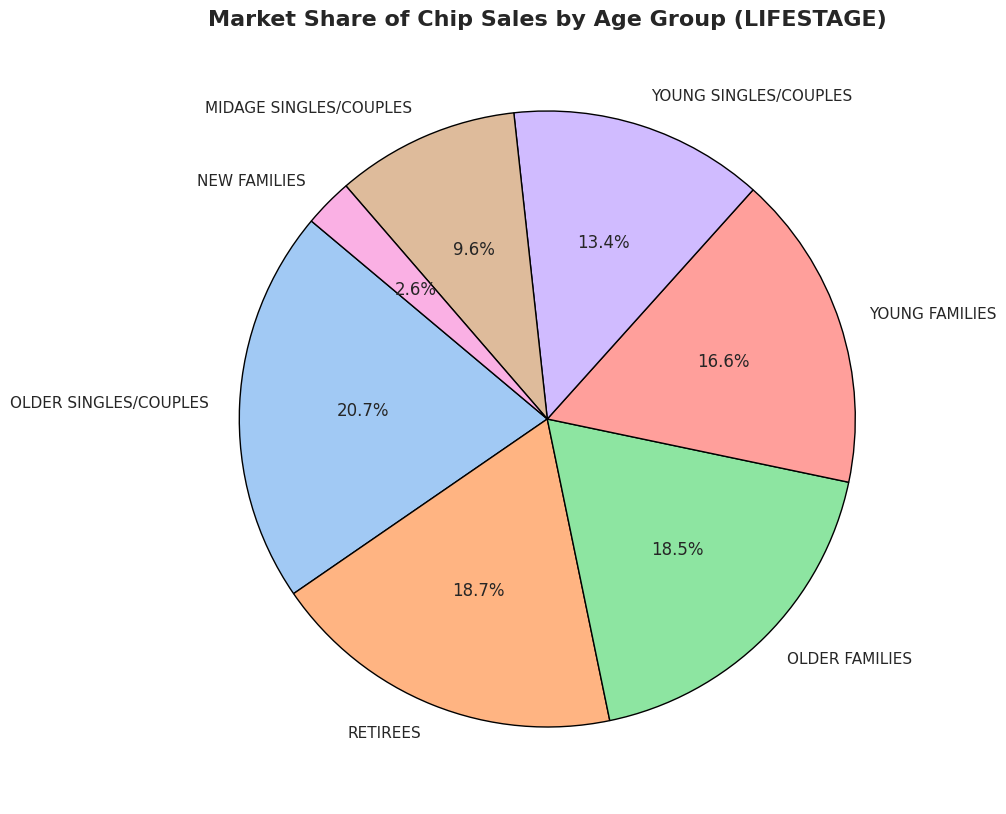

/tmp/ipykernel_17/2649303920.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


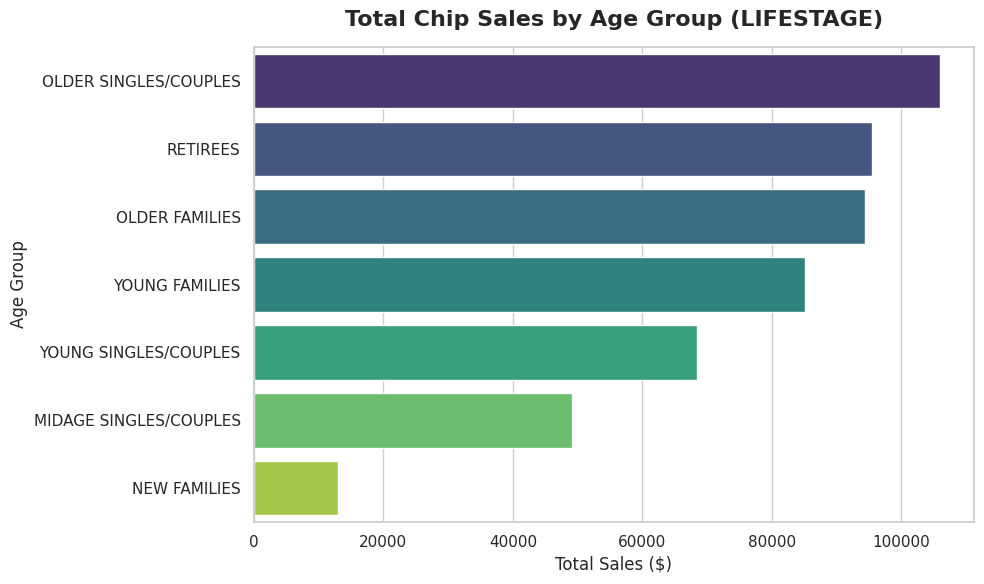

In [11]:
# checking the market share of the chips product between the Customer Catgory
customer_catagory = """
                    SELECT PREMIUM_CUSTOMER AS CATAGORY, SUM(TOT_SALES) AS TOTAL_SALES
                    FROM merge_result
                    WHERE PROD_NAME ILIKE 'c%hip%'
                    GROUP BY  CATAGORY
                    ORDER BY TOTAL_SALES DESC"""
customer_result = duckdb.query(customer_catagory).to_df()
customer_result.head()
pie_data = customer_result.groupby('CATAGORY')['TOTAL_SALES'].sum()

plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140, 
        colors=['#ff9999','#66b3ff','#99ff99'], wedgeprops={'edgecolor': 'black'})

plt.title('Market Share of Chip Sales by Customer Category', fontsize=16, fontweight='bold')
plt.show()

# now checking the share only by the LIFESTAGE 
lifestage = """
            SELECT LIFESTAGE, SUM(TOT_SALES) AS TOTAL_SALES
            FROM merge_result
            WHERE PROD_NAME ILIKE '%chip%'
            GROUP BY LIFESTAGE,
            ORDER BY TOTAL_SALES DESC
            """
lifestage_result = duckdb.query(lifestage).to_df()
print(lifestage_result.head(10))

# PIE CHART for Market Share
plt.figure(figsize=(10, 10))
pie_data_life = lifestage_result.set_index('LIFESTAGE')['TOTAL_SALES']

colors = sns.color_palette('pastel')[0:len(pie_data_life)]

plt.pie(pie_data_life, labels=pie_data_life.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})

plt.title('Market Share of Chip Sales by Age Group (LIFESTAGE)', fontsize=16, fontweight='bold')
plt.show()

# BAR CHART for Total Sales by Lifestage
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=lifestage_result, 
    x='TOTAL_SALES', 
    y='LIFESTAGE', 
    palette='viridis'
)

plt.title('Total Chip Sales by Age Group (LIFESTAGE)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.tight_layout()
plt.show()

#by the mainstream customer catagory are the leading in chips by 40.2% share and running to it is the budget 
# catagories with 33.7% they are the top chips consumers 
# the older pepole are the one with famlies they tend to buy the most amount of chips by the revenue 

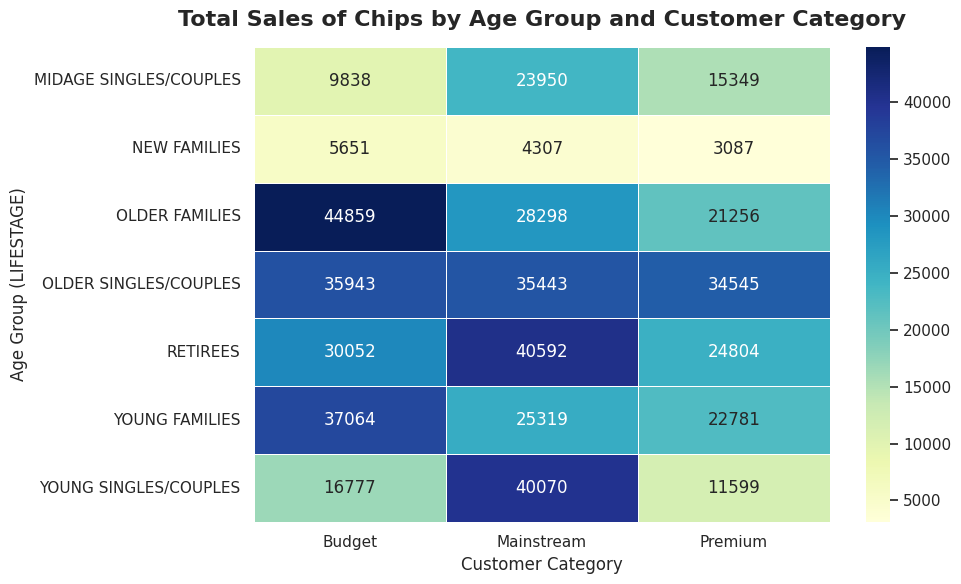

In [12]:
#in this segment we will try to find the top chips purchasing age group and Customer catagory 
age_groups = """
             SELECT LIFESTAGE,PREMIUM_CUSTOMER AS CATAGORY, SUM(TOT_SALES) AS TOTAL_SALES
             FROM merge_result
             WHERE PROD_NAME ILIKE '%chip%'
             GROUP BY LIFESTAGE, PREMIUM_CUSTOMER
             ORDER BY TOTAL_SALES DESC
             """
catagory = duckdb.query(age_groups).to_df()
catagory.head()
sales_pivot = catagory.pivot_table(values='TOTAL_SALES', 
                                   index='LIFESTAGE', 
                                   columns='CATAGORY', 
                                   aggfunc='sum')

# Plotting the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(sales_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)

plt.title('Total Sales of Chips by Age Group and Customer Category', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Age Group (LIFESTAGE)', fontsize=12)
plt.xlabel('Customer Category', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# I try to find the out which store has the most revenue genrated by sellig the chips 
store = """
        SELECT STORE_NBR AS STORE, SUM(TOT_SALES) AS CHIPS_SALES,
        COUNT(DISTINCT TXN_ID) AS TOTAL_TRANSACTIONS,
        SUM(PROD_QTY) AS TOTAL_PACKETS_SOLD
        FROM merge_result
        WHERE PROD_NAME ILIKE '%chip%'
        GROUP BY STORE
        ORDER BY CHIPS_SALES DESC
        """
unique_store = duckdb.query(store).to_df()
unique_store.head()
# store number 226 is the one most selling the chips by both the volume and revenue

,STORE,CHIPS_SALES,TOTAL_TRANSACTIONS,TOTAL_PACKETS_SOLD
0,226,4435.7,542,1077.0
1,88,4049.8,497,998.0
2,165,4033.1,492,973.0
3,237,4011.6,492,974.0
4,4,4003.5,488,970.0


In [14]:
# My insight is are the follwings 
#1.the most selling chips is the one called smiths 330gm but by the revenue the whole catagory of big pack
# of chips are not the one leading the revenue or the quantity. the real winners are medium catagory(170-175gm) making
# up more then 67% of the revenue. large chips(330+gm) are taking 7.1%. small chips(110gm) are taking 23.1%
# and rest are the others 
#2. the most chips purchasing one by age groups are the one with families and which are older
#3. the store number 226 are the one making the most revenue of the chips 